### Pandas

```
이름    국어 영어 수학
홍길동   90  80 100
이순신   70  90 85
강감찬  100  95 90
```

- Python List —> 행과 열을 관리하기 어럽다.
- NumPy —> 숫자 계산은 편하지만 컬럼명이 없다.
- Pandas —> 표 그대로 관리할 수 있다.


### Series

Series는 하나의 컬럼(Column) 을 표현하는 자료형이다.


In [3]:
import numpy as np

score = np.array([90, 80, 100])
print(score)
print(type(score))  # <class 'numpy.ndarray'>

[ 90  80 100]
<class 'numpy.ndarray'>


In [2]:
import pandas as pd

score = pd.Series([90, 80, 100])
print(score)
print(type(score))  # <class 'pandas.Series'>

0     90
1     80
2    100
dtype: int64
<class 'pandas.Series'>


### DataFrame

> **행(Row)과 열(Column)을 가진 2차원 표 형태의 자료구조이다.**

Pandas에서 가장 중요한 객체


In [5]:
import pandas as pd

student = {"name": ["홍길동", "이순신", "강감찬"], "score": [90, 80, 100]}

print(type(student))  # <class 'dict'>

df = pd.DataFrame(student)

print(df)
print(type(df))  # <class 'pandas.DataFrame'>

<class 'dict'>
  name  score
0  홍길동     90
1  이순신     80
2  강감찬    100
<class 'pandas.DataFrame'>


### CSV 읽기


In [113]:
import pandas as pd

df = pd.read_csv("student.csv")

print(type(df))  # <class 'pandas.DataFrame'>
print(df)

<class 'pandas.DataFrame'>
    이름   국어  영어   수학
0  홍길동   90  80  100
1  이순신   70  90   85
2  강감찬  100  95   90


### CSV 저장


In [10]:
# 새로운 csv 파일로 저장
df.to_csv("result.csv", index=False)

df.to_csv("result2.csv")

### DataFrame 정보

#### info()

> DataFrame의 전체 구조와 상태를 요약해서 보여주는 함수이다.

- 컬럼 정보
- 데이터 타입
- 결측치 여부
- 메모리 사용량


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   이름      3 non-null      str  
 1    국어     3 non-null      int64
 2    영어     3 non-null      int64
 3    수학     3 non-null      int64
dtypes: int64(3), str(1)
memory usage: 228.0 bytes


### describe()

`describe()`는 **DataFrame의 숫자(Number) 컬럼에 대한 기본 통계 정보를 한 번에 계산해 주는 함수**

데이터 분석을 시작할 때 가장 먼저 사용하는 함수 중 하나이다.


In [13]:
df.describe()  # 숫자 데이터 컬럼만 출력

,국어,영어,수학
count,3.000000,3.000000,3.000000
mean,86.666667,88.333333,91.666667
std,15.275252,7.637626,7.637626
min,70.000000,80.000000,85.000000
25%,80.000000,85.000000,87.500000
50%,90.000000,90.000000,90.000000
75%,95.000000,92.500000,95.000000
max,100.000000,95.000000,100.000000


### 이상치(Outlier)

> 다른 데이터들과 비교했을 때 유난히 크거나 작은 값을 말한다.

즉,

대부분의 데이터와 너무 멀리 떨어져 있는 데이터를 의미한다.


In [51]:
# DataFrame의 앞부분(상위 데이터)을 조회하는 함수- 처음 5개 행
df.head()

,이름,국어,영어,수학
A,홍길동,90,80,100
B,이순신,70,90,85
C,강감찬,100,95,90


In [18]:
# 원하는 개수 만큼
df.head(1)

,이름,국어,영어,수학
0,홍길동,90,80,100


In [19]:
# DataFrame의 마지막(하위 데이터)을 조회하는 함수 - 마지막 5개 행
df.tail()

,이름,국어,영어,수학
0,홍길동,90,80,100
1,이순신,70,90,85
2,강감찬,100,95,90


In [20]:
# 원하는 개수 만큼
df.tail(2)

,이름,국어,영어,수학
1,이순신,70,90,85
2,강감찬,100,95,90


In [23]:
# 컬럼 선택
print(df["이름"])

0    홍길동
1    이순신
2    강감찬
Name: 이름, dtype: str


In [64]:
print(df[["이름"," 국어"]])

    이름   국어
A  홍길동   90
B  이순신   70
C  강감찬  100


In [28]:
print(df)

    이름   국어   영어   수학
0  홍길동   90   80  100
1  이순신   70   90   85
2  강감찬  100   95   90


In [35]:
print(df.iloc[0])

이름     홍길동
 국어     90
 영어     80
 수학    100
Name: 0, dtype: object


In [37]:
print(df.iloc[0:2])

    이름   국어   영어   수학
0  홍길동   90   80  100
1  이순신   70   90   85


In [38]:
print(df.iloc[2:1])

Empty DataFrame
Columns: [이름,  국어,  영어,  수학]
Index: []


In [39]:
print(df.loc[0]) # Label 이름 기반, 0번 인덱스 행 선택

이름     홍길동
 국어     90
 영어     80
 수학    100
Name: 0, dtype: object


### 행(Row) 선택하기 - iloc()와 loc()

#### iloc란?
> **행과 열의 위치(Position, Index 번호)** 로 데이터를 선택하는 함수이다.

즉,

> **숫자로 접근한다.**

---
#### loc란?

`loc`는

> **행과 열의 이름(Label)** 으로 데이터를 선택하는 함수이다.


In [41]:
# index 변경: index 개수에 맞게 새로운 index를 지정
df.index=["A","B","C"]

print(df)

    이름   국어   영어   수학
A  홍길동   90   80  100
B  이순신   70   90   85
C  강감찬  100   95   90


In [44]:
# print(df.loc[0]) # error 발생, index가 0이 없기 때문에
print(df.iloc[0])

이름     홍길동
 국어     90
 영어     80
 수학    100
Name: A, dtype: object


In [45]:
print(df.loc["A":"C"])

    이름   국어   영어   수학
A  홍길동   90   80  100
B  이순신   70   90   85
C  강감찬  100   95   90


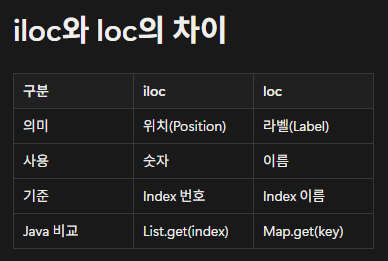

In [47]:
# 행, 열 선택
print(df.iloc[1, 2])

90


In [49]:
print(df.iloc[0, 0])

홍길동


In [66]:
print(df.loc["B"])

이름     이순신
 국어     70
 영어     90
 수학     85
Name: B, dtype: object


#### 실습 1
첫 번째 학생 정보를 출력하세요.

In [58]:
print(df.iloc[0])

이름     홍길동
 국어     90
 영어     80
 수학    100
Name: A, dtype: object


#### 실습 2
마지막 학생 정보를 출력하세요.

In [57]:
print(df.iloc[-1])

이름     강감찬
 국어    100
 영어     95
 수학     90
Name: C, dtype: object


#### 실습 3
두 번째 학생의 수학 점수를 출력하세요.

In [56]:
print(df.iloc[1, 3])

85


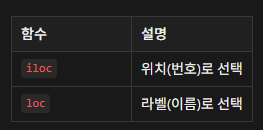

---

In [63]:
print(df[df[" 국어"] >= 90])

    이름   국어   영어   수학
A  홍길동   90   80  100
C  강감찬  100   95   90


In [62]:
df

,이름,국어,영어,수학
A,홍길동,90,80,100
B,이순신,70,90,85
C,강감찬,100,95,90


In [67]:
# 컬럼 선택
print(df["이름"])

A    홍길동
B    이순신
C    강감찬
Name: 이름, dtype: str


In [68]:
print(df[["이름"," 수학"]])

    이름   수학
A  홍길동  100
B  이순신   85
C  강감찬   90


In [69]:
# 번호(Index)로 선택
print(df.iloc[0])

이름     홍길동
 국어     90
 영어     80
 수학    100
Name: A, dtype: object


In [70]:
print(df.iloc[0:2])

    이름   국어   영어   수학
A  홍길동   90   80  100
B  이순신   70   90   85


In [77]:
# 이름(Label)으로 선택
# print(df.loc[" 국어"])

In [79]:
# 조건 검색
print(df[df[" 국어"] >= 90])

    이름   국어   영어   수학
A  홍길동   90   80  100
C  강감찬  100   95   90


In [80]:
# 여러 조건
df[(df[" 영어"] >= 90) & (df[" 수학"] >= 90)]

,이름,국어,영어,수학
C,강감찬,100,95,90


In [81]:
# 컬럼 추가
df["총합"] = df[" 국어"] + df[" 영어"] + df[" 수학"]

In [82]:
# 평균 추가
df["평균"] = df["총합"] / 3

In [83]:
# 컬럼 삭제
df.drop("평균", axis=1)

,이름,국어,영어,수학,총합
A,홍길동,90,80,100,270
B,이순신,70,90,85,245
C,강감찬,100,95,90,285


In [84]:
# 정렬
df.sort_values(" 국어")

,이름,국어,영어,수학,총합,평균
B,이순신,70,90,85,245,81.666667
A,홍길동,90,80,100,270,90.000000
C,강감찬,100,95,90,285,95.000000


In [85]:
# 정렬: 내림차순
df.sort_values(" 국어", ascending=False)

,이름,국어,영어,수학,총합,평균
C,강감찬,100,95,90,285,95.000000
A,홍길동,90,80,100,270,90.000000
B,이순신,70,90,85,245,81.666667


#### unique()

In [87]:
# df["dept"].unique()

---

### CSV를 이용한 groupby() 실습

In [89]:
import pandas as pd

df = pd.read_csv("department_score.csv", encoding="utf-8")
df

,name,department,gender,kor,eng,math
0,홍길동,개발팀,남,90,85,100
1,이순신,개발팀,남,75,80,70
2,강감찬,인사팀,남,88,92,95
3,유관순,인사팀,여,60,70,65
4,김유신,영업팀,남,100,90,100
5,신사임당,영업팀,여,45,55,60
6,안중근,개발팀,남,78,82,84
7,윤봉길,영업팀,남,92,88,96
8,세종대왕,인사팀,남,68,75,72
9,김구,개발팀,남,85,90,88


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        10 non-null     str  
 1   department  10 non-null     str  
 2   gender      10 non-null     str  
 3   kor         10 non-null     int64
 4   eng         10 non-null     int64
 5   math        10 non-null     int64
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [91]:
df.describe()

,kor,eng,math
count,10.000000,10.00000,10.000000
mean,78.100000,80.70000,83.000000
std,16.649658,11.46056,15.129074
min,45.000000,55.00000,60.000000
25%,69.750000,76.25000,70.500000
50%,81.500000,83.50000,86.000000
75%,89.500000,89.50000,95.750000
max,100.000000,92.00000,100.000000


In [92]:
# 부서별 인원 수
df["department"].value_counts()

department
개발팀    4
인사팀    3
영업팀    3
Name: count, dtype: int64

In [93]:
# 부서별 평균 국어 점수
df.groupby("department")["kor"].mean()

department
개발팀    82.0
영업팀    79.0
인사팀    72.0
Name: kor, dtype: float64

In [94]:
# 부서별 평균 점수
df.groupby("department")[["kor", "eng", "math"]].mean()

,kor,eng,math
department,,,
개발팀,82.0,84.250000,85.500000
영업팀,79.0,77.666667,85.333333
인사팀,72.0,79.000000,77.333333


In [95]:
# 부서별 최고 국어 점수
df.groupby("department")["kor"].max()

department
개발팀     90
영업팀    100
인사팀     88
Name: kor, dtype: int64

In [96]:
# 부서별 최저 국어 점수
df.groupby("department")["kor"].min()

department
개발팀    75
영업팀    45
인사팀    60
Name: kor, dtype: int64

In [97]:
# 부서별 평균 총점
df["total"]=df["kor"]+df["eng"]+df["math"] # total 컬럼 생성

df.groupby("department")["total"].mean()

department
개발팀    251.750000
영업팀    242.000000
인사팀    228.333333
Name: total, dtype: float64

In [98]:
df

,name,department,gender,kor,eng,math,total
0,홍길동,개발팀,남,90,85,100,275
1,이순신,개발팀,남,75,80,70,225
2,강감찬,인사팀,남,88,92,95,275
3,유관순,인사팀,여,60,70,65,195
4,김유신,영업팀,남,100,90,100,290
5,신사임당,영업팀,여,45,55,60,160
6,안중근,개발팀,남,78,82,84,244
7,윤봉길,영업팀,남,92,88,96,276
8,세종대왕,인사팀,남,68,75,72,215
9,김구,개발팀,남,85,90,88,263


In [101]:
# 부서별 평균 점수(내림차순)
df.groupby("department")["total"].mean().sort_values(ascending = False)

department
개발팀    251.750000
영업팀    242.000000
인사팀    228.333333
Name: total, dtype: float64

In [102]:
# 부서별 + 성별 평균 점수
df.groupby(["department", "gender"])["total"].mean()

department  gender
개발팀         남         251.75
영업팀         남         283.00
            여         160.00
인사팀         남         245.00
            여         195.00
Name: total, dtype: float64

In [103]:
# agg() 함수를 사용하면 여러 통계를 한 번에 계산
# Aggregate
df.groupby("department")["kor"].agg(["count", "mean", "max", "min"])

,count,mean,max,min
department,,,,
개발팀,4,82.0,90,75
영업팀,3,79.0,100,45
인사팀,3,72.0,88,60


In [104]:
# 컬럼 이름 변경
result = df.groupby("department")["kor"].agg(
    학생수="count", 평균="mean", 최고점="max", 최저점="min"
)

print(result)

            학생수    평균  최고점  최저점
department                     
개발팀           4  82.0   90   75
영업팀           3  79.0  100   45
인사팀           3  72.0   88   60


In [105]:
# 여러 과목을 한번에 계산
df.groupby("department")[["kor", "eng"]].agg(["mean", "max", "min"])

kor                 eng        
            mean  max min       mean max min
department                                  
개발팀         82.0   90  75  84.250000  90  80
영업팀         79.0  100  45  77.666667  90  55
인사팀         72.0   88  60  79.000000  92  70

https://app.notion.com/p/Pandas-387a7a6c42ce80ea8727e48fd5b767db
-> Numpy, Pandas 실습!

---

In [108]:
import pandas as pd

df = pd.read_csv("titanic.csv", encoding="utf-8")
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


---

### Matplotlib 시각화 하기

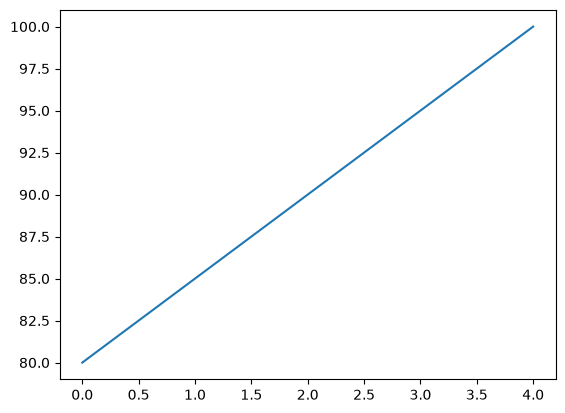

In [112]:
import matplotlib.pyplot as plt

# scores = [60, 85, 20, 95, 50]
scores = [80, 85, 90, 95, 100]

plt.plot(scores)
plt.show()

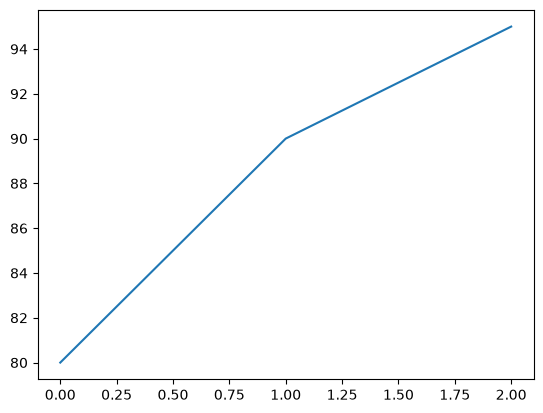

In [116]:
df["영어"].plot()
plt.show()

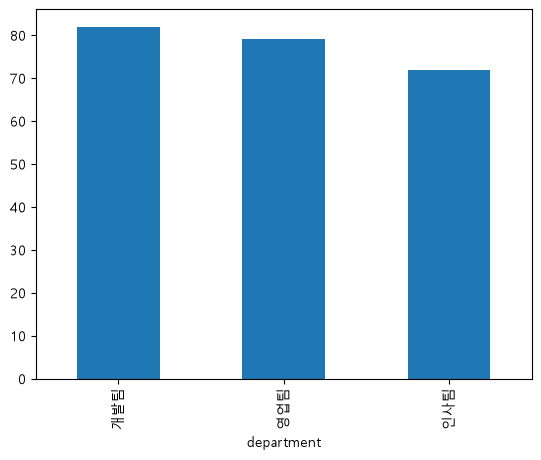

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Windows 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"

# 마이너스(-) 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("department_score.csv", encoding="utf-8")

avg = df.groupby("department")["kor"].mean()

avg.plot(kind="bar")

plt.show()

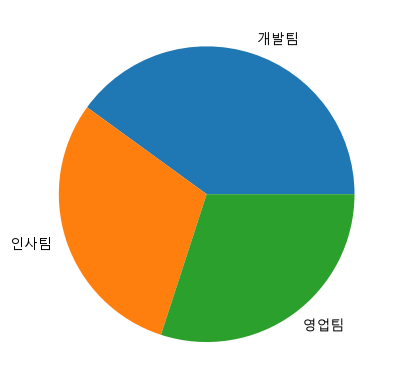

In [121]:
df["department"].value_counts().plot(kind="pie")

plt.show()

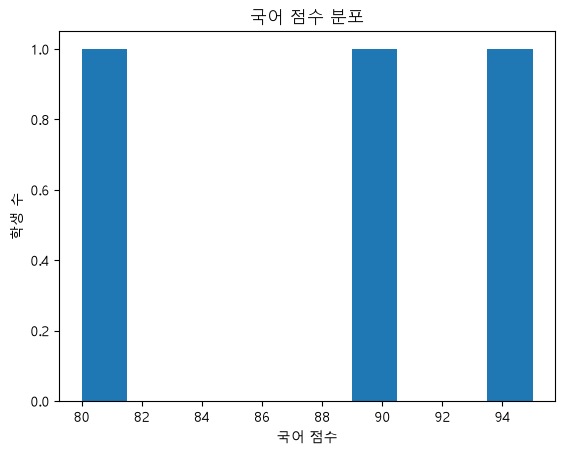

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("student.csv")

df["영어"].plot(kind="hist")

plt.title("국어 점수 분포")
plt.xlabel("국어 점수")
plt.ylabel("학생 수")

plt.show()

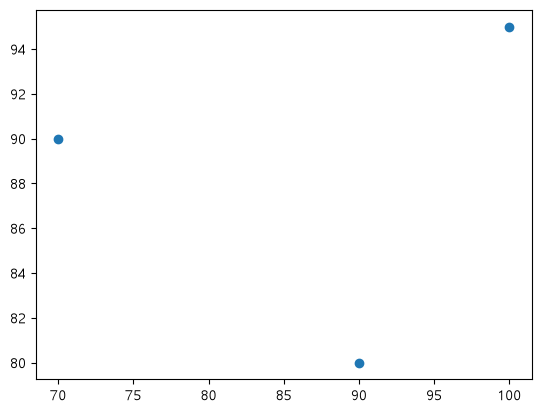

In [123]:
plt.scatter(df["국어"], df["영어"])

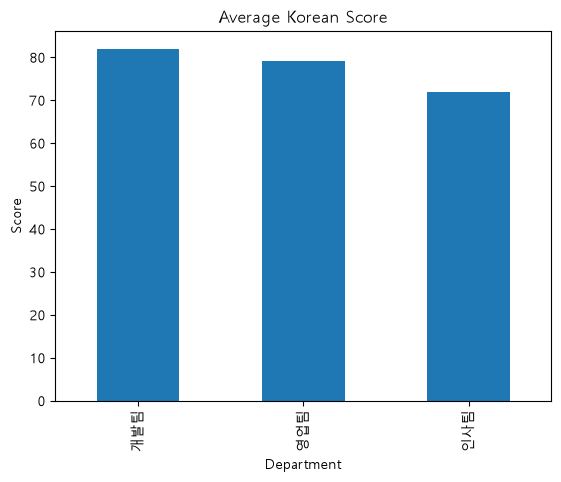

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("department_score.csv")

avg = df.groupby("department")["kor"].mean()

avg.plot(kind="bar")

plt.title("Average Korean Score")

plt.xlabel("Department")

plt.ylabel("Score")

plt.show()

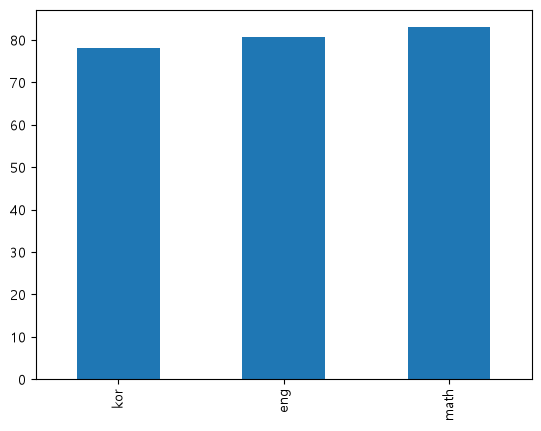

In [127]:
subject = df[["kor", "eng", "math"]].mean()

subject.plot(kind="bar")

plt.show()

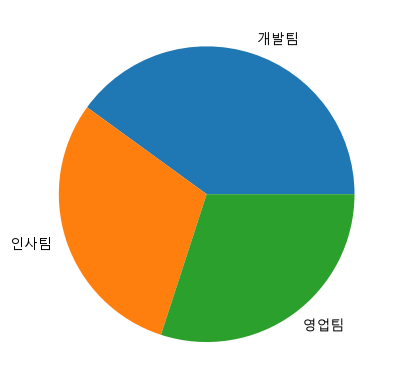

In [128]:
df["department"].value_counts().plot(kind="pie")

plt.show()

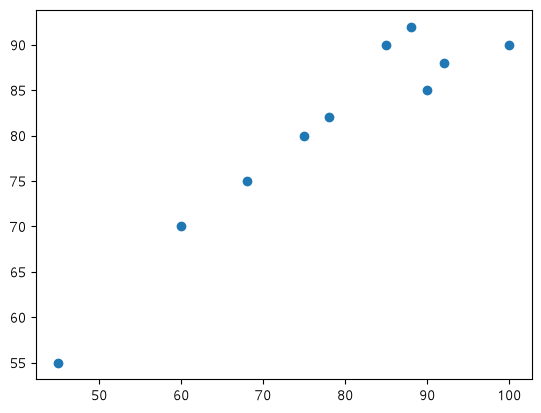

In [129]:
plt.scatter(df["kor"], df["eng"])

plt.show()

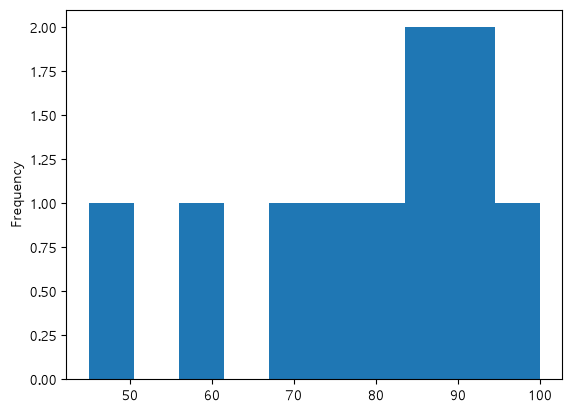

In [130]:
df["kor"].plot(kind="hist")

plt.show()

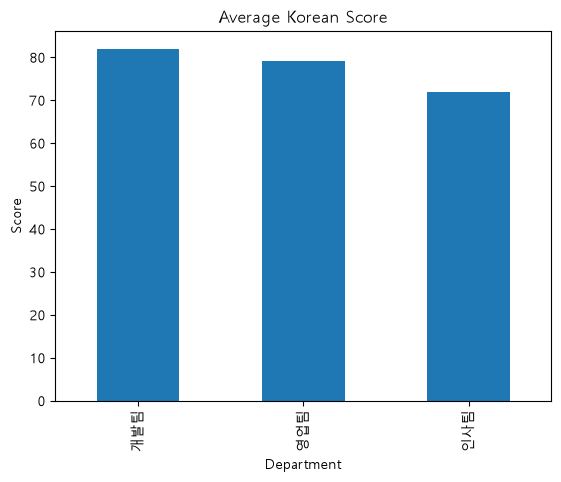

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 읽기
df = pd.read_csv("department_score.csv")

# 부서별 kor 평균 계산
avg = df.groupby("department")["kor"].mean()

# 막대 그래프 출력
avg.plot(kind="bar")

plt.title("Average Korean Score")

plt.xlabel("Department")

plt.ylabel("Score")

plt.show()